In [4]:
!pip install tensorflow opencv-python matplotlib numpy scikit-learn kagglehub

In [5]:
import kagglehub

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Dataset path: /kaggle/input/face-mask-dataset


With mask images   : 3725
Without mask images: 3828


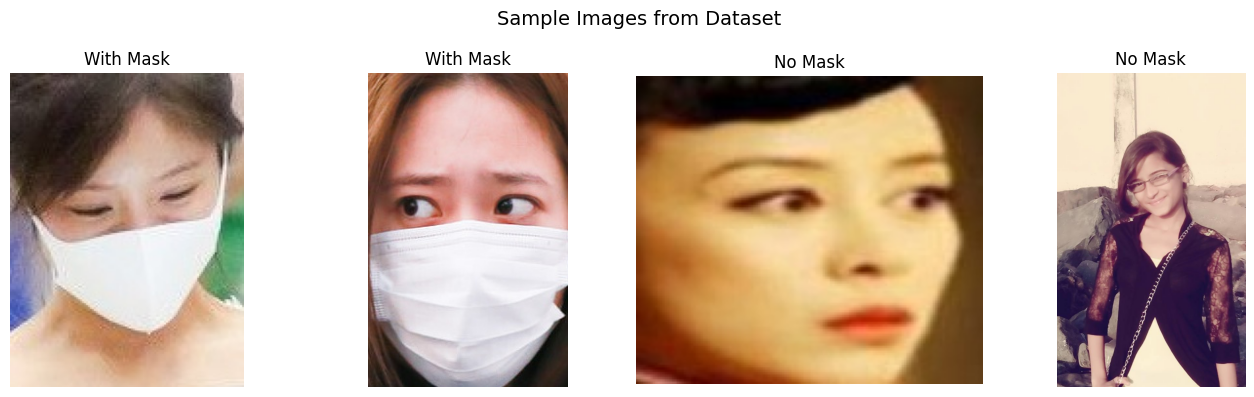

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data"
with_mask_path = os.path.join(dataset_path, "with_mask")
without_mask_path = os.path.join(dataset_path, "without_mask")

print("With mask images   :", len(os.listdir(with_mask_path)))
print("Without mask images:", len(os.listdir(without_mask_path)))

# Show 4 sample images
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, (folder, label) in enumerate([(with_mask_path, "With Mask"),
                                      (without_mask_path, "No Mask")]):
    for j in range(2):
        img_name = os.listdir(folder)[j]
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i * 2 + j].imshow(img)
        axes[i * 2 + j].set_title(label)
        axes[i * 2 + j].axis("off")

plt.suptitle("Sample Images from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import cv2

dataset_path = "/root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data"
with_mask_path    = os.path.join(dataset_path, "with_mask")
without_mask_path = os.path.join(dataset_path, "without_mask")

IMG_SIZE = 96  # ⬇️ Reduced from 224 to 96 — saves 5x RAM

data, labels = [], []

for label, folder in enumerate([without_mask_path, with_mask_path]):
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        data.append(img)
        labels.append(label)

data   = np.array(data, dtype=np.float32) / 255.0
labels = to_categorical(np.array(labels), num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"✅ Done! RAM usage is now safe.")

Train: 6042, Test: 1511
✅ Done! RAM usage is now safe.


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Use 96x96 input to match our smaller images
base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=(96, 96, 3))
base_model.trainable = False

head = base_model.output
head = GlobalAveragePooling2D()(head)
head = Dense(64, activation="relu")(head)
head = Dropout(0.5)(head)
head = Dense(2, activation="softmax")(head)

model = Model(inputs=base_model.input, outputs=head)
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

print("✅ Lightweight model built!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Lightweight model built!


In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=16   # ⬇️ Smaller batch = less RAM per step
)

model.save("mask_detector.h5")
print("✅ Model trained and saved!")

Epoch 1/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 59s 138ms/step - accuracy: 0.9628 - loss: 0.1059 - val_accuracy: 0.9722 - val_loss: 0.0678
Epoch 2/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 49s 129ms/step - accuracy: 0.9828 - loss: 0.0514 - val_accuracy: 0.9815 - val_loss: 0.0585
Epoch 3/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 48s 127ms/step - accuracy: 0.9882 - loss: 0.0339 - val_accuracy: 0.9788 - val_loss: 0.0645
Epoch 4/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 82s 127ms/step - accuracy: 0.9891 - loss: 0.0311 - val_accuracy: 0.9808 - val_loss: 0.0567
Epoch 5/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - accuracy: 0.9917 - loss: 0.0246 - val_accuracy: 0.9808 - val_loss: 0.0735
Epoch 6/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 85s 131ms/step - accuracy: 0.9926 - loss: 0.0223 - val_accuracy: 0.9801 - val_loss: 0.0589
Epoch 7/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 48s 127ms/step - accuracy: 0.9952 - loss: 0.0177 - val_accuracy: 0.9828 - val_loss: 0.0565
Epoch 8/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 49s 129ms/step - accuracy: 0.9955 - loss: 0

✅ Model trained and saved!


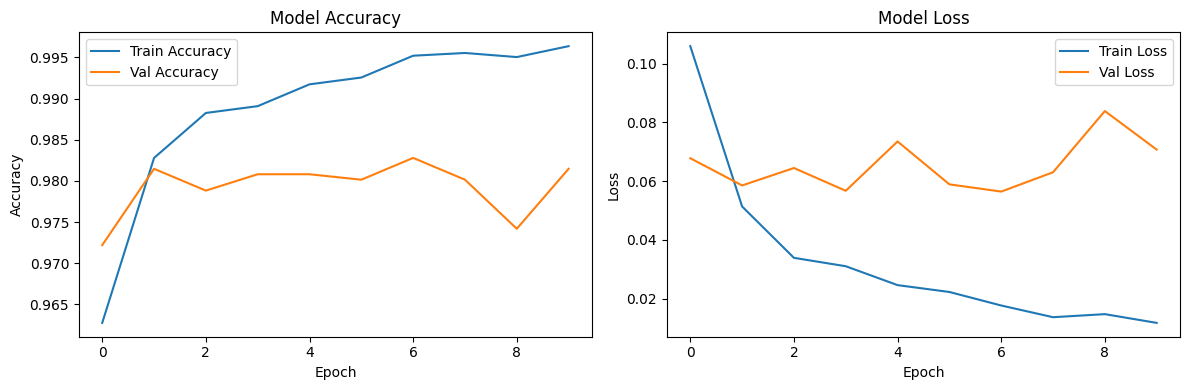

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy * 100:.2f}%")

48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.9815 - loss: 0.0707

Test Loss     : 0.0707
Test Accuracy : 98.15%


/tmp/ipykernel_14845/2516894286.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14845/2516894286.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


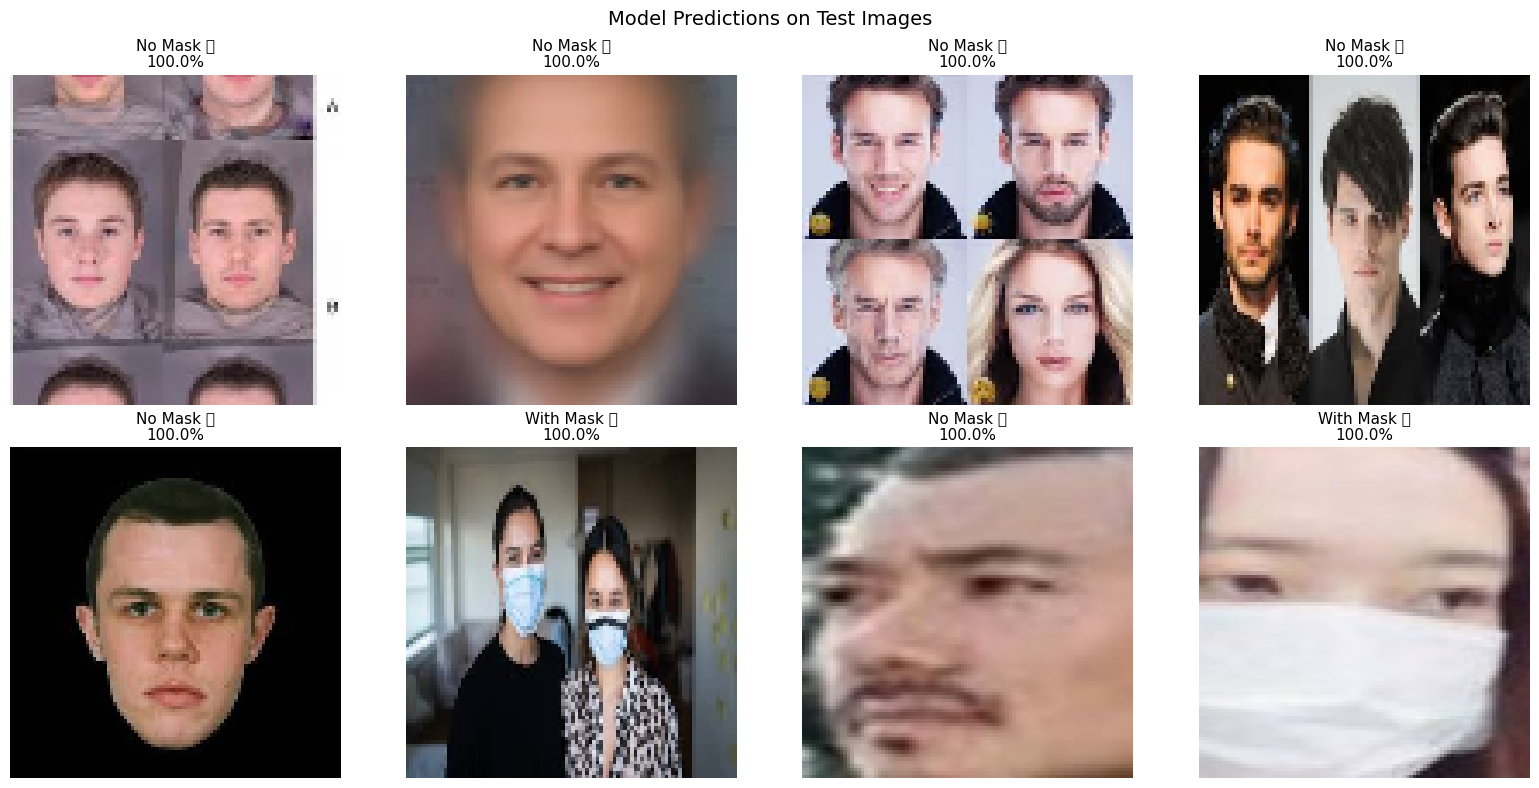

In [10]:
import numpy as np
import matplotlib.pyplot as plt

CLASSES = ["No Mask ❌", "With Mask ✅"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img  = X_test[i]
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    label      = CLASSES[np.argmax(pred)]
    confidence = np.max(pred) * 100

    axes[i].imshow(img)
    axes[i].set_title(f"{label}\n{confidence:.1f}%", fontsize=11)
    axes[i].axis("off")

plt.suptitle("Model Predictions on Test Images", fontsize=14)
plt.tight_layout()
plt.show()

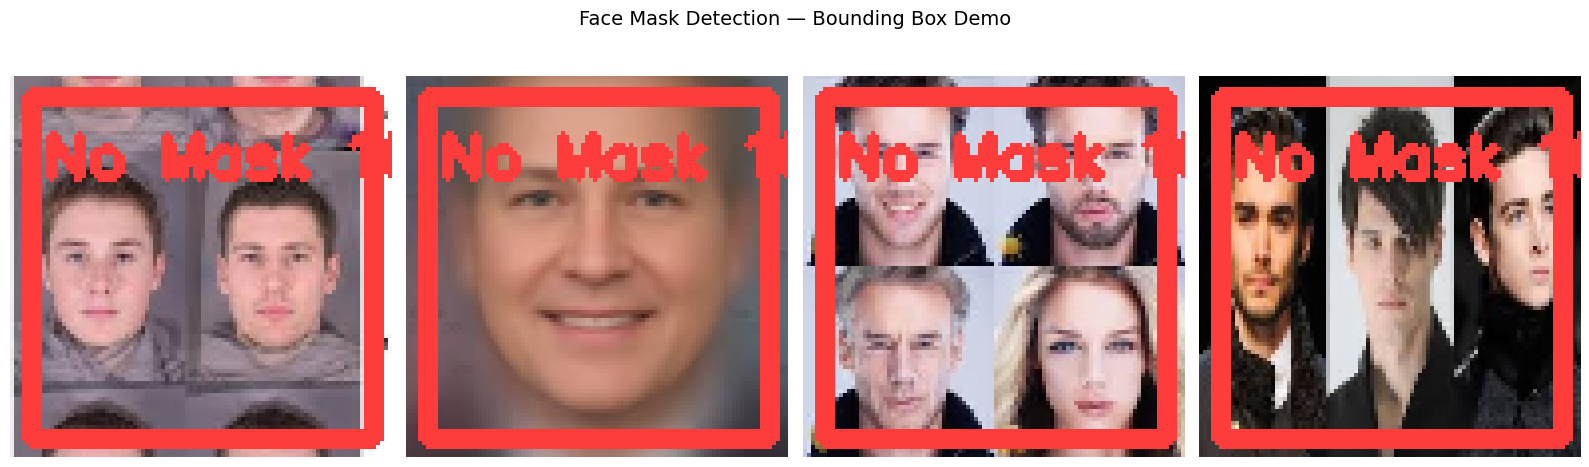

🎯 Screenshot this output for your LinkedIn post!


In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASSES = ["No Mask", "With Mask"]
COLORS  = [(255, 60, 60), (60, 200, 60)]  # Red = No Mask, Green = With Mask

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i in range(4):
    img_orig = (X_test[i] * 255).astype(np.uint8).copy()
    pred     = model.predict(np.expand_dims(X_test[i], axis=0), verbose=0)
    idx      = np.argmax(pred)
    label    = CLASSES[idx]
    color    = COLORS[idx]
    conf     = np.max(pred) * 100

    h, w = img_orig.shape[:2]
    cv2.rectangle(img_orig, (5, 5), (w - 5, h - 5), color, 3)
    cv2.putText(img_orig, f"{label} {conf:.1f}%",
                (8, 25), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, color, 2)

    axes[i].imshow(img_orig)
    axes[i].axis("off")

plt.suptitle("Face Mask Detection — Bounding Box Demo", fontsize=14)
plt.tight_layout()
plt.show()
print("🎯 Screenshot this output for your LinkedIn post!")

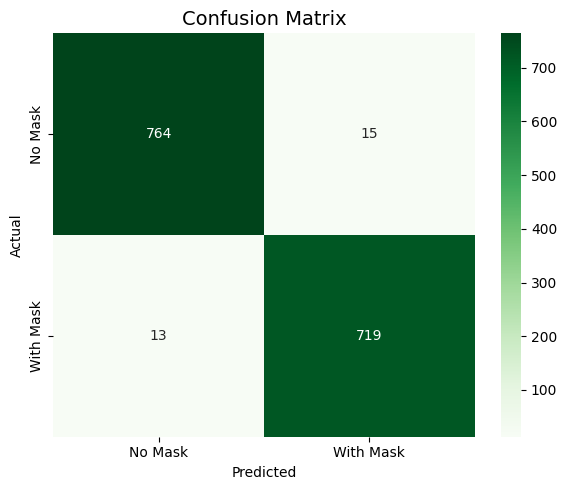


Classification Report:
              precision    recall  f1-score   support

     No Mask       0.98      0.98      0.98       779
   With Mask       0.98      0.98      0.98       732

    accuracy                           0.98      1511
   macro avg       0.98      0.98      0.98      1511
weighted avg       0.98      0.98      0.98      1511



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred  = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred,  axis=1)
y_true_classes = np.argmax(y_test,  axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Mask", "With Mask"],
            yticklabels=["No Mask", "With Mask"])
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                             target_names=["No Mask", "With Mask"]))